In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# !pip install shap

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# original data source: https://www.kaggle.com/uciml/german-credit
# data source with risk categories: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

credit_filename = 'German_credit_risk_data/german_credit_data2.csv'

credits = pd.read_csv(credit_filename, index_col=0)

credits

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [2]:
stat_columns = credits.describe()
stat_columns

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [3]:
credits_1 = credits.drop(stat_columns.columns, axis=1)
for c in credits_1.columns:
    print(c)
    print(Counter(credits_1[c]).most_common(10))

Sex
[('male', 690), ('female', 310)]
Housing
[('own', 713), ('rent', 179), ('free', 108)]
Saving accounts
[('little', 603), (nan, 183), ('moderate', 103), ('quite rich', 63), ('rich', 48)]
Checking account
[(nan, 394), ('little', 274), ('moderate', 269), ('rich', 63)]
Purpose
[('car', 337), ('radio/TV', 280), ('furniture/equipment', 181), ('business', 97), ('education', 59), ('repairs', 22), ('domestic appliances', 12), ('vacation/others', 12)]
Risk
[('good', 700), ('bad', 300)]


In [4]:
credits

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [5]:
X = pd.get_dummies(credits_1, columns=credits_1.columns, drop_first=False, dtype=int)
src_index, val_index = np.array([c.split('_',1) for c in X.columns]).T
col_index = pd.MultiIndex.from_arrays([src_index, val_index], 
                                      names=['source', 'value'])
# X.columns = col_index

table1 = pd.DataFrame(data=X.values, index=X.index, columns=col_index)
print(table1.shape)
table1

(1000, 22)


source    Sex      Housing          Saving accounts                           \
value  female male    free own rent          little moderate quite rich rich   
0           0    1       0   1    0               0        0          0    0   
1           1    0       0   1    0               1        0          0    0   
2           0    1       0   1    0               1        0          0    0   
3           0    1       1   0    0               1        0          0    0   
4           0    1       1   0    0               1        0          0    0   
..        ...  ...     ...  ..  ...             ...      ...        ...  ...   
995         1    0       0   1    0               1        0          0    0   
996         0    1       0   1    0               1        0          0    0   
997         0    1       0   1    0               1        0          0    0   
998         0    1       1   0    0               1        0          0    0   
999         0    1       0   1    0               0        1          0    0   

source Checking account  ...  Purpose                                    \
value            little  ... business car domestic appliances education   
0                     1  ...        0   0                   0         0   
1                     0  ...        0   0                   0         0   
2                     0  ...        0   0                   0         1   
3                     1  ...        0   0                   0         0   
4                     1  ...        0   1                   0         0   
..                  ...  ...      ...  ..                 ...       ...   
995                   0  ...        0   0                   0         0   
996                   1  ...        0   1                   0         0   
997                   0  ...        0   0                   0         0   
998                   1  ...        0   0                   0         0   
999                   0  ...        0   1                   0         0   

source                                                      Risk       
value  furniture/equipment radio/TV repairs vacation/others  bad good  
0                        0        1       0               0    0    1  
1                        0        1       0               0    1    0  
2                        0        0       0               0    0    1  
3                        1        0       0               0    0    1  
4                        0        0       0               0    1    0  
..                     ...      ...     ...             ...  ...  ...  
995                      1        0       0               0    0    1  
996                      0        0       0               0    0    1  
997                      0        1       0               0    0    1  
998                      0        1       0               0    1    0  
999                      0        0       0               0    0    1  

[1000 rows x 22 columns]

# create balanced training and test sets

In [6]:
Counter(table1[('Risk','good')]).most_common()

[(1, 700), (0, 300)]

In [7]:
# !pip install imblearn

import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

data = table1.copy()
# Splitting features and target variable
X = data.drop(columns=[('Risk','good')])
y = data[('Risk','good')]

# Using RandomUnderSampler to balance classes
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Creating a new balanced DataFrame
balanced_data = pd.concat([X_resampled, y_resampled], axis=1)

# Splitting into training (80%) and testing (20%) sets
train, test = train_test_split(balanced_data, test_size=0.2, stratify=balanced_data[('Risk','good')], random_state=42)

X_train = train.drop(columns=[('Risk','good'),('Risk','bad')])
y_train = train[('Risk','good')]

X_test = test.drop(columns=[('Risk','good'),('Risk','bad')])
y_test = test[('Risk','good')]

print(Counter(train[('Risk','good')]).most_common(), Counter(test[('Risk','good')]).most_common())

[(0, 240), (1, 240)] [(0, 60), (1, 60)]


# create decision trees to separate good from not good risks

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# Initialize Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=420)

# Train the model
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
print(f'Accuracy for training set: {accuracy_score(y_train, y_train_pred):.2f}')

# Make predictions
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy for test set: {accuracy:.2f}')


Accuracy for training set: 0.82
Accuracy for test set: 0.60


# plot feature importance
##  Gini Importance (Mean Decrease in Impurity - MDI)
Measures how much each feature reduces impurity (e.g., Gini index) across all trees.

Features used in earlier splits (closer to the root) and more frequently used contribute more.

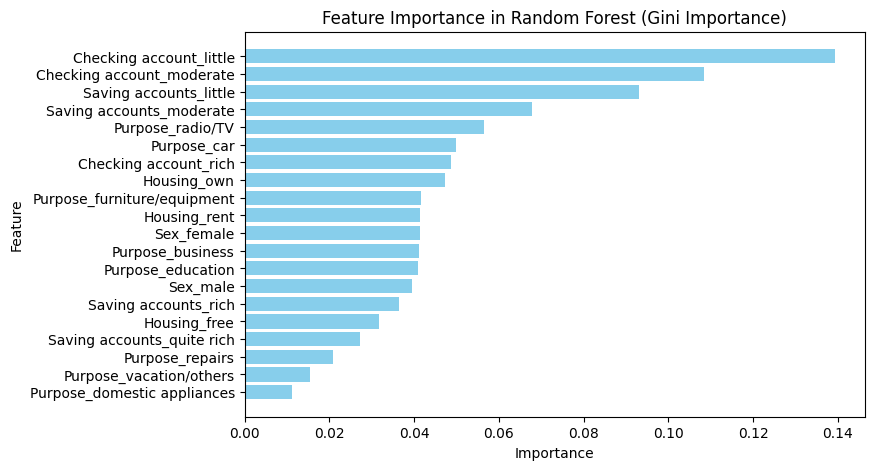

In [58]:

feature_names = ['_'.join(c) for c in X_train.columns]  # Get feature names

feature_importance = model.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# # Print feature importance
# print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest (Gini Importance)')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()


# Permutation Importance (Mean Decrease in Accuracy - MDA)
Randomly shuffles a feature and observes how much accuracy drops.

If accuracy decreases significantly, the feature is important.

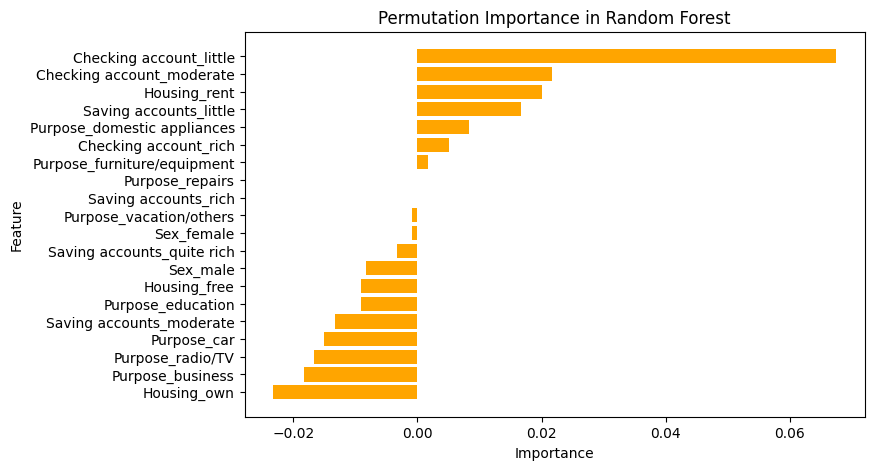

In [65]:
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color='orange')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Permutation Importance in Random Forest')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()


# SHAP

## Feature Importance in SHAP (Game Theory-Based Approach)
SHAP (SHapley Additive exPlanations) is based on cooperative game theory.

It assigns each feature an importance score based on how much it changes the model's prediction compared to the average prediction.

Unlike Random Forest feature importance, SHAP considers feature interactions.

For each prediction, SHAP computes how much each feature contributes to increasing or decreasing the output.

The SHAP summary plot gives a global view of feature importance and interactions.

<Figure size 640x480 with 0 Axes>

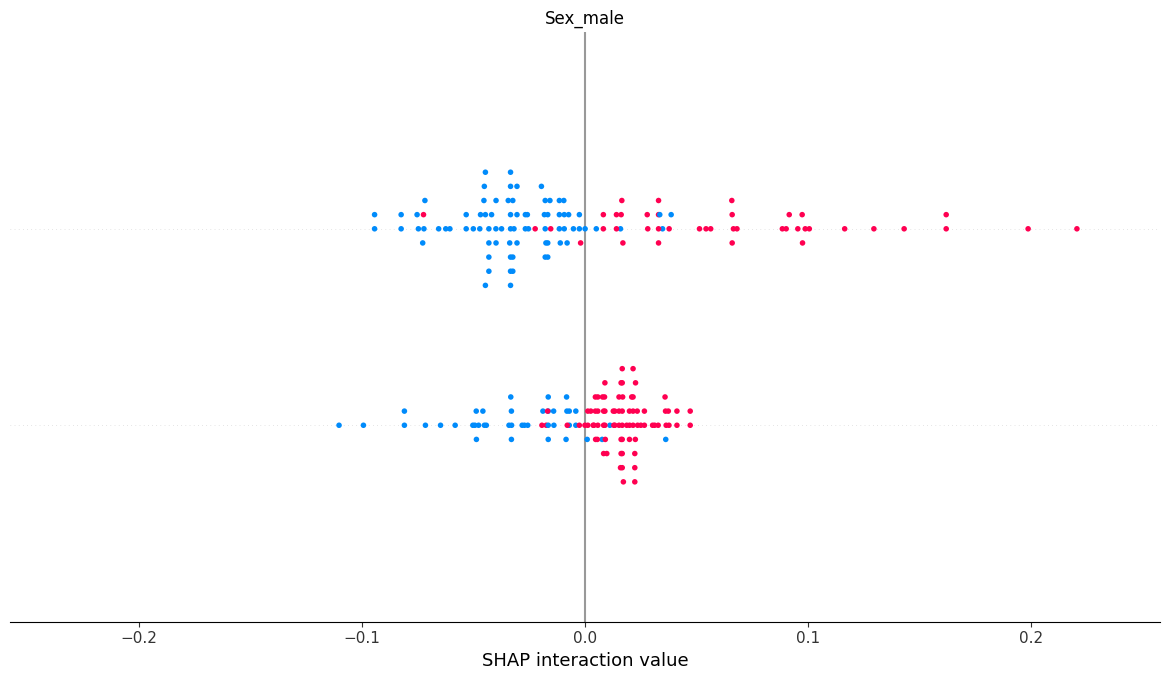

In [66]:
import shap

explainer = shap.TreeExplainer(model)  # Works for tree-based models like Random Forest
shap_values = explainer.shap_values(X_test)

# Summary Plot (Global Importance)
shap.summary_plot(shap_values, X_test, feature_names=feature_names)


## permutations for a subset of the features

['Sex_female', 'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent', 'Saving accounts_little', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_little', 'Checking account_moderate', 'Checking account_rich', 'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']

['Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']


<Figure size 640x480 with 0 Axes>

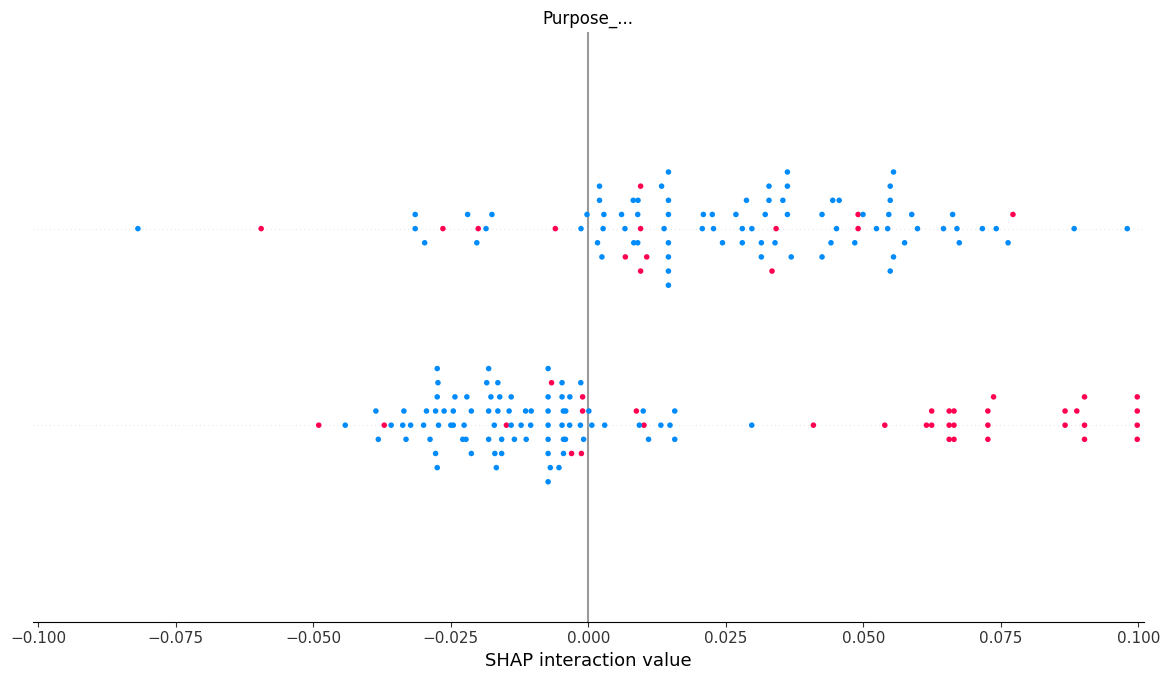

In [57]:
print(feature_names)
print()
s = 16
print(feature_names[s:])
shap.summary_plot(shap_values.values[:,s:], X_test.iloc[:,s:], feature_names=feature_names[s:])